In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import host_utils as utils 
from astropy.cosmology import Planck15
from astropy import units as u

In [2]:
import scienceplots
plt.style.use(['science'])
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

In [3]:

pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop,max_Mstar_tolerance=0.15,max_z_tolerance=0.1)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0', 
    brahma_simName_array[5]: '#014636'  
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[10,10,10,1])
    if brahma_simName_array[i] == 'SM5_LW10_LOWSPIN_RICH_TNG':
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.6,max_z_tolerance=0.2)
    else:
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.15,max_z_tolerance=0.2)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=12,zbin_width=0.3,min_N_values=10)


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.1,min_N_values=10)
print('Brahma common zbins:',brahma_zbins)


sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = brahma_sim_zbins
#sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

For TNG50:


finding controls: 100%|██████████| 504/504 [00:03<00:00, 138.05it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:411: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 16
SM5_TNG


finding controls: 100%|██████████| 773/773 [00:00<00:00, 25820.25it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:705: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:709: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_massive_pop = self.Mdot_massive_control_pop/self.MBH_massive_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:712: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_luminous_pop = self.Mdot_luminous_control_pop/self.MBH_luminous_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 172
number of processable mergers with valid controls:
581
[31, 40, 44, 65, 68, 83, 62, 39, 25, 13]
SM5_LW10_TNG


...

Number of cases where a close enough match is not found within the acceptable tolerance: 228
number of processable mergers with valid controls:
574
[40, 36, 51, 55, 62, 79, 78, 49, 18, 11]
SM5_LW10_LOWSPIN_TNG


finding controls: 100%|██████████| 488/488 [00:00<00:00, 26626.34it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 123
number of processable mergers with valid controls:
356
[27, 21, 21, 35, 28, 58, 45, 26, 24, 16, 10]
SM5_LW10_LOWSPIN_RICH_TNG


finding controls: 100%|██████████| 175/175 [00:00<00:00, 25574.13it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 25
number of processable mergers with valid controls:
149
[11, 12, 25, 20, 11, 11, 12, 10]
[55, 56, 54, 63, 65, 55, 68, 51]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 4.5]
Brahma common zbins: [0.  0.2 0.8 1.5 2.2 3.1 4.1 5.1 7.1]


## Do mergers have higher AGN luminosity than controls across z bins?

In [4]:
def plot_Lbol_mergers_and_controls(ax,sim_objs,sim_name,binnum=10,z_l=0,z_u=4,radiative_efficiency=0.2):
    Lbol_mergers = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_merging_pop,radiative_efficiency)
    Lbol_control = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_control_pop,radiative_efficiency)

    z_mask = (sim_objs[sim_name].z_merging_pop >= z_l) & (sim_objs[sim_name].z_merging_pop < z_u)
    valid_luminosity_mask = (Lbol_mergers > 0) & (Lbol_control > 0) & z_mask
    Lbol_mergers = Lbol_mergers[valid_luminosity_mask]
    Lbol_control = Lbol_control[valid_luminosity_mask]

    median_Lbol_mergers = np.median(Lbol_mergers)
    median_Lbol_control = np.median(Lbol_control)

    print(f"Median Lbol for Merging: {median_Lbol_mergers:.2e} erg/s")
    print(f"Median Lbol for Control: {median_Lbol_control:.2e} erg/s")
    print("Mergers have a {:.2e} times higher median Lbol than Control".format(median_Lbol_mergers/median_Lbol_control))

    
    ax.hist(np.log10(Lbol_mergers), bins=binnum, alpha=0.5, label='Merging', color='red', histtype='step')
    ax.hist(np.log10(Lbol_control), bins=binnum, alpha=0.5, label='Control', color='black', histtype='step')
    ax.axvline(np.log10(median_Lbol_mergers), color='red', linestyle='dashed', linewidth=1)
    ax.axvline(np.log10(median_Lbol_control), color='black', linestyle='dashed', linewidth=1)
    
    return ax

In [5]:
def AGN_excess_in_mergers(sim_objs,sim_name,Lthreshold=43,z_l=0,z_u=4,radiative_efficiency=0.2,verbose=True):
    Lbol_mergers = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_merging_pop,radiative_efficiency)
    Lbol_control = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_control_pop,radiative_efficiency)

    z_mask = (sim_objs[sim_name].z_merging_pop >= z_l) & (sim_objs[sim_name].z_merging_pop < z_u)
    valid_luminosity_mask = (Lbol_mergers > 0) & (Lbol_control > 0) & z_mask
    valid_luminosity_above_threshold_mask = (Lbol_mergers > 10**Lthreshold) & (Lbol_control > 0) & z_mask
    
    Lbol_mergers = Lbol_mergers[valid_luminosity_mask]
    Lbol_control = Lbol_control[valid_luminosity_mask]

    MBH_mergers = sim_objs[sim_name].MBH_merging_pop[valid_luminosity_mask]
    MBH_control = sim_objs[sim_name].MBH_control_pop[valid_luminosity_mask]

    if verbose:
        print(np.median(np.log10(MBH_mergers)),np.median(np.log10(MBH_control)))

    mergers_higher_Lbol_count = 0
    
    for i in range(Lbol_mergers.shape[0]):
        if (Lbol_mergers[i] > Lbol_control[i]):
            mergers_higher_Lbol_count += 1
    
    total_count = Lbol_mergers.shape[0]
    excess_fraction = mergers_higher_Lbol_count / total_count if total_count > 0 else 0
    # standard binomial error: sigma = sqrt(p*(1-p)/N) where p is the fraction and N is the total count
    excess_fraction_std = np.sqrt(excess_fraction * (1 - excess_fraction) / total_count) if total_count > 0 else np.nan

    if verbose:
        print(f"Fraction of mergers with Lbol > control: {excess_fraction:.2%} ± {excess_fraction_std:.2%} ({mergers_higher_Lbol_count}/{total_count})")

    if np.sum(valid_luminosity_above_threshold_mask) == 0:
        if verbose:
            print(f"No valid luminosity values above the threshold of 10^{Lthreshold} erg/s for {sim_name} in the redshift range {z_l} to {z_u}.")
        return excess_fraction, excess_fraction_std, np.nan, np.nan
    
    else:
        Lbol_mergers = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_merging_pop,radiative_efficiency)
        Lbol_control = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_control_pop,radiative_efficiency)
        Lbol_mergers_above_threshold = Lbol_mergers[valid_luminosity_above_threshold_mask]
        Lbol_control_above_threshold = Lbol_control[valid_luminosity_above_threshold_mask]
        mergers_higher_Lbol_above_threshold_count = 0
        for i in range(Lbol_mergers_above_threshold.shape[0]):
            if Lbol_mergers_above_threshold[i] > Lbol_control_above_threshold[i]:
                mergers_higher_Lbol_above_threshold_count += 1
        total_count_above_threshold = Lbol_mergers_above_threshold.shape[0]
        excess_fraction_above_threshold = mergers_higher_Lbol_above_threshold_count / total_count_above_threshold if total_count_above_threshold > 0 else 0
        # standard binomial error: sigma = sqrt(p*(1-p)/N) where p is the fraction and N is the total count
        excess_fraction_above_threshold_std = np.sqrt(excess_fraction_above_threshold * (1 - excess_fraction_above_threshold) / total_count_above_threshold) if total_count_above_threshold > 0 else np.nan
        
        if verbose:
            print(f"Fraction of mergers with Lbol > control above the threshold of 10^{Lthreshold} erg/s: {excess_fraction_above_threshold:.2%} ± {excess_fraction_above_threshold_std:.2%} ({mergers_higher_Lbol_above_threshold_count}/{total_count_above_threshold})")
        return excess_fraction, excess_fraction_std, excess_fraction_above_threshold, excess_fraction_above_threshold_std

In [6]:
Lbol_excess_results = {}
for sim in sim_names:
    print(f"Processing {sim}...")
    excess_fraction,_,_,_ = AGN_excess_in_mergers(sim_objs,sim_name=sim,Lthreshold=43,z_l=0,z_u=20,radiative_efficiency=0.2)
    Lbol_excess_results[sim] = excess_fraction


Processing SM5_TNG...
6.618540489411613 6.613666772344674
Fraction of mergers with Lbol > control: 48.58% ± 2.33% (223/459)
Fraction of mergers with Lbol > control above the threshold of 10^43 erg/s: 64.29% ± 9.06% (18/28)
Processing SM5_LW10_TNG...
6.216816215244269 6.208063128936202
Fraction of mergers with Lbol > control: 48.83% ± 2.55% (188/385)
Fraction of mergers with Lbol > control above the threshold of 10^43 erg/s: 84.21% ± 5.92% (32/38)
Processing SM5_DFD_3_TNG...
6.432561120806233 6.451764963352774
Fraction of mergers with Lbol > control: 45.61% ± 2.15% (244/535)
Fraction of mergers with Lbol > control above the threshold of 10^43 erg/s: 68.12% ± 5.61% (47/69)
Processing SM5_LW10_DFD_3_TNG...
6.019240461241235 6.021417197447444
Fraction of mergers with Lbol > control: 48.44% ± 2.28% (233/481)
Fraction of mergers with Lbol > control above the threshold of 10^43 erg/s: 71.67% ± 5.82% (43/60)
Processing SM5_LW10_LOWSPIN_TNG...
6.084812408087829 6.117351996753626
Fraction of mer

Processing TNG50 for excess fraction above luminosity thresholds...
Processing SM5_DFD_3_TNG for excess fraction above luminosity thresholds...
Processing SM5_LW10_LOWSPIN_RICH_TNG for excess fraction above luminosity thresholds...


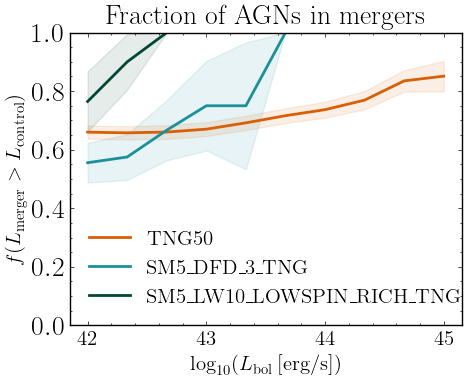

In [7]:
hostplot.set_plot_style(spinewidth=1,linewidth=3, titlesize=20,labelsize=15,xlabelsize=15,ylabelsize=20,legendsize=15,bold=True)

fig,ax = plt.subplots(1,1,figsize=(5,4))
sim_names_to_plot = ['TNG50','SM5_DFD_3_TNG','SM5_LW10_LOWSPIN_RICH_TNG']

Lthreshold = np.linspace(42,45,10)

for sim in sim_names_to_plot:
    fAGN_excess = []
    fAGN_excess_err = []
    print(f"Processing {sim} for excess fraction above luminosity thresholds...")
    for Lt in Lthreshold:
        if sim == 'TNG50':
            z_l, z_u = 0, 40
        else:
            z_l, z_u = 4, 40
        _,_, excess_fraction_above_threshold, excess_fraction_above_threshold_std = AGN_excess_in_mergers(
            sim_objs,sim_name=sim,Lthreshold=Lt,z_l=z_l,z_u=z_u,radiative_efficiency=0.2,verbose=False)
        fAGN_excess.append(excess_fraction_above_threshold)
        fAGN_excess_err.append(excess_fraction_above_threshold_std)
    
    fAGN_excess = np.array(fAGN_excess)
    fAGN_excess_err = np.array(fAGN_excess_err)
    
    ax.plot(Lthreshold, fAGN_excess, linewidth=2, label=sim, color=sim_colors[sim])
    ax.fill_between(Lthreshold, fAGN_excess - fAGN_excess_err, fAGN_excess + fAGN_excess_err, 
                     alpha=0.1, color=sim_colors[sim])

ax.set_xlabel(r'$\log_{10}(L_{\mathrm{bol}} \, [\mathrm{erg/s}])$')
ax.set_ylabel('$f(L_{\mathrm{merger}} > L_{\mathrm{control}})$')
ax.set_title('Fraction of AGNs in mergers')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()

In [9]:
def Lbol_excess_in_mergers(sim_objs,sim_name,Lthreshold=43,z_l=0,z_u=4,radiative_efficiency=0.2,verbose=True):
    Lbol_mergers = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_merging_pop,radiative_efficiency)
    Lbol_control = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_control_pop,radiative_efficiency)

    if sim_name == 'TNG50':
        z_mask = (sim_objs[sim_name].z_merging_pop >= 0) & (sim_objs[sim_name].z_merging_pop < 40)
    else:
        z_mask = (sim_objs[sim_name].z_merging_pop >= 4) & (sim_objs[sim_name].z_merging_pop < 40)

    valid_luminosity_mask = (Lbol_mergers > 0) & (Lbol_control > 0) & z_mask
    valid_luminosity_above_threshold_mask = (Lbol_mergers > 10**Lthreshold) & (Lbol_control > 0) & z_mask
    
    Lbol_mergers_filtered = Lbol_mergers[valid_luminosity_mask]
    Lbol_control_filtered = Lbol_control[valid_luminosity_mask]

    MBH_mergers = sim_objs[sim_name].MBH_merging_pop[valid_luminosity_mask]
    MBH_control = sim_objs[sim_name].MBH_control_pop[valid_luminosity_mask]

    if verbose:
        print(np.median(np.log10(MBH_mergers)),np.median(np.log10(MBH_control)))

    # Calculate ratios for all valid data
    ratios_all = Lbol_mergers_filtered / Lbol_control_filtered
    median_ratio_all = np.median(ratios_all)
    q1_all, q3_all = np.percentile(ratios_all, [25, 75])
    iqr_all = q3_all - q1_all

    if verbose:
        print(f"Median Lbol ratio (merger/control): {median_ratio_all:.2f}, IQR: {iqr_all:.2f}")

    if np.sum(valid_luminosity_above_threshold_mask) == 0:
        if verbose:
            print(f"No valid luminosity values above the threshold of 10^{Lthreshold} erg/s for {sim_name} in the redshift range {z_l} to {z_u}.")
        return median_ratio_all, iqr_all, np.nan, np.nan
    
    else:
        Lbol_mergers = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_merging_pop,radiative_efficiency)
        Lbol_control = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_control_pop,radiative_efficiency)
        Lbol_mergers_above_threshold = Lbol_mergers[valid_luminosity_above_threshold_mask]
        Lbol_control_above_threshold = Lbol_control[valid_luminosity_above_threshold_mask]
        
        # Calculate ratios for above-threshold data
        ratios_above_threshold = Lbol_mergers_above_threshold / Lbol_control_above_threshold
        median_ratio_above_threshold = np.median(ratios_above_threshold)
        q1_above, q3_above = np.percentile(ratios_above_threshold, [25, 75])
        iqr_above_threshold = q3_above - q1_above
        
        if verbose:
            print(f"Median Lbol ratio (merger/control) above threshold 10^{Lthreshold} erg/s: {median_ratio_above_threshold:.2f}, IQR: {iqr_above_threshold:.2f}")
        
        return median_ratio_all, iqr_all, median_ratio_above_threshold, iqr_above_threshold

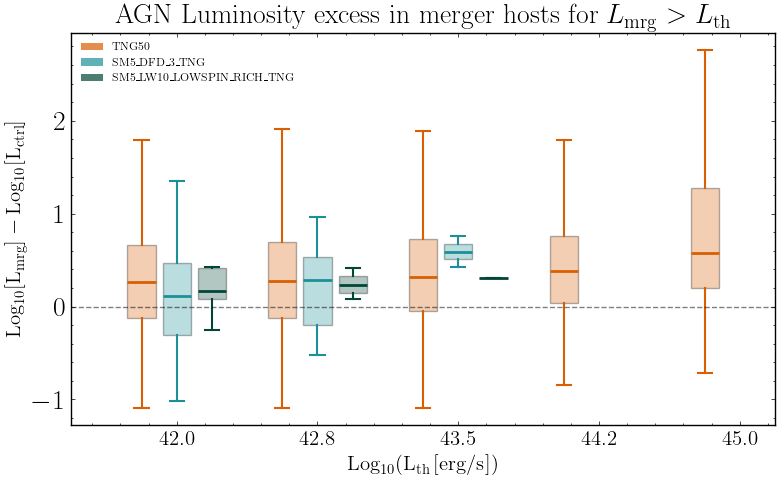

In [8]:
hostplot.set_plot_style(spinewidth=1,linewidth=3, titlesize=20,labelsize=15,xlabelsize=15,ylabelsize=20,legendsize=8,bold=True)

fig,ax = plt.subplots(1,1,figsize=(8,5))
sim_names_to_plot = ['TNG50','SM5_DFD_3_TNG','SM5_LW10_LOWSPIN_RICH_TNG']

Lthreshold = np.linspace(42,45,5)
box_width = 0.25
x_positions = np.arange(len(Lthreshold))

# Collect all ratio data for each simulation
all_box_data = {sim: [] for sim in sim_names_to_plot}
all_positions = {sim: [] for sim in sim_names_to_plot}

for j, Lt in enumerate(Lthreshold):
    for i, sim in enumerate(sim_names_to_plot):
        # Calculate ratios directly
        Lbol_mergers = utils.Lbol_from_BHAR(sim_objs[sim].Mdot_merging_pop, 0.2)
        Lbol_control = utils.Lbol_from_BHAR(sim_objs[sim].Mdot_control_pop, 0.2)
        
        if sim == 'TNG50':
            z_mask = (sim_objs[sim].z_merging_pop >= 0) & (sim_objs[sim].z_merging_pop < 40)
        else:
            z_mask = (sim_objs[sim].z_merging_pop >= 4) & (sim_objs[sim].z_merging_pop < 40)
        
        valid_luminosity_above_threshold_mask = (Lbol_mergers > 10**Lt) & (Lbol_control > 0) & z_mask
        
        if np.sum(valid_luminosity_above_threshold_mask) > 0:
            Lbol_mergers_above = Lbol_mergers[valid_luminosity_above_threshold_mask]
            Lbol_control_above = Lbol_control[valid_luminosity_above_threshold_mask]
            ratios = Lbol_mergers_above / Lbol_control_above
            log_ratios = np.log10(ratios)
            
            all_box_data[sim].append(log_ratios)
            all_positions[sim].append(x_positions[j] + (i - 1) * box_width)

# Create boxplots
for i, sim in enumerate(sim_names_to_plot):
    bp = ax.boxplot(all_box_data[sim], positions=all_positions[sim], widths=box_width*0.8,
                    patch_artist=True, showfliers=False, 
                    boxprops=dict(facecolor=sim_colors[sim], alpha=0.3),
                    medianprops=dict(color=sim_colors[sim], linewidth=2),
                    whiskerprops=dict(color=sim_colors[sim], linewidth=1.5),
                    capprops=dict(color=sim_colors[sim], linewidth=1.5))
    
    # Create a proxy artist for legend
    for patch in bp['boxes']:
        patch.set_label(sim)
        break


ax.set_xlabel(r'$\rm Log_{10}(L_{\mathrm{th}} \, [\mathrm{erg/s}])$')
ax.set_ylabel(r'$\rm Log_{10} [ L_{\mathrm{mrg}}] - Log_{10}[L_{\mathrm{ctrl}}]$')

ax.set_title(r'AGN Luminosity excess in merger hosts for $L_{\rm mrg} > L_{\rm th}$')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Equal (ratio=1)')
ax.set_xticks(x_positions)
ax.set_xticklabels([f'{L:.1f}' for L in Lthreshold])

# Manual legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=sim_colors[sim], alpha=0.7, label=sim) for sim in sim_names_to_plot]
#egend_elements.append(plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1))
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()

Median Lbol for Merging: 1.43e+44 erg/s
Median Lbol for Control: 6.17e+43 erg/s
Mergers have a 2.32e+00 times higher median Lbol than Control
Median Lbol for Merging: 1.79e+42 erg/s
Median Lbol for Control: 2.38e+42 erg/s
Mergers have a 7.50e-01 times higher median Lbol than Control
Median Lbol for Merging: 9.63e+41 erg/s
Median Lbol for Control: 7.33e+41 erg/s
Mergers have a 1.31e+00 times higher median Lbol than Control


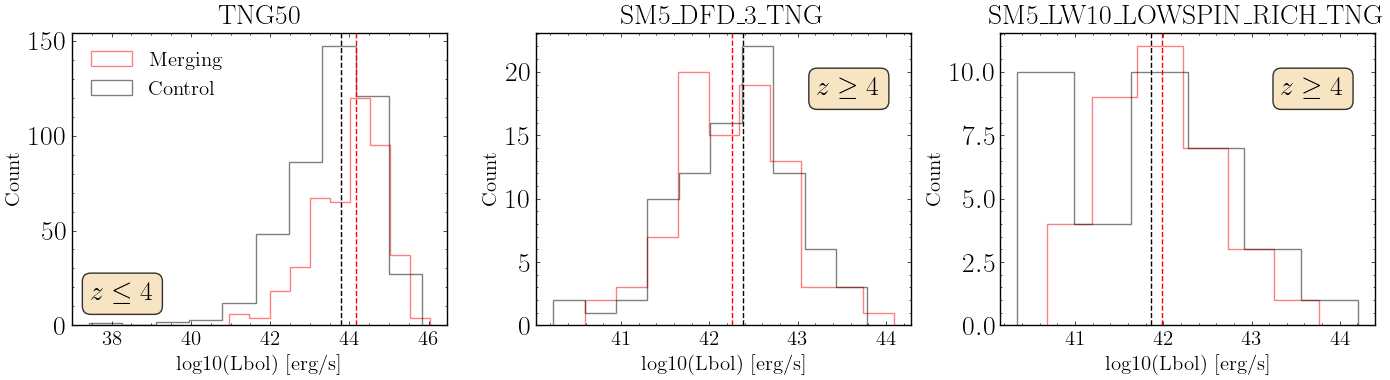

In [9]:
hostplot.set_plot_style(spinewidth=1,linewidth=3, titlesize=20,labelsize=15,xlabelsize=15,ylabelsize=20,legendsize=15,bold=True)

fig,ax = plt.subplots(1,3,figsize=(14,4))
ax1 = plot_Lbol_mergers_and_controls(ax[0],sim_objs,'TNG50',z_l=0,z_u=4)
ax2 = plot_Lbol_mergers_and_controls(ax[1],sim_objs,'SM5_DFD_3_TNG',z_l=4,z_u=15)
ax3 = plot_Lbol_mergers_and_controls(ax[2],sim_objs,'SM5_LW10_LOWSPIN_RICH_TNG',binnum=6,z_l=4,z_u=15)
ax1.set_title('TNG50')
ax2.set_title('SM5_DFD_3_TNG')
ax3.set_title('SM5_LW10_LOWSPIN_RICH_TNG')
ax1.set_xlabel('log10(Lbol) [erg/s]')
ax2.set_xlabel('log10(Lbol) [erg/s]')
ax3.set_xlabel('log10(Lbol) [erg/s]')
ax1.set_ylabel('Count')
ax2.set_ylabel('Count')
ax3.set_ylabel('Count')

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.05, 0.15, fr'$z \leq 4$', transform=ax1.transAxes, fontsize=20, verticalalignment='top', bbox=props, weight='bold')
ax2.text(0.75, 0.85, fr'$z \geq 4$', transform=ax2.transAxes, fontsize=20, verticalalignment='top', bbox=props, weight='bold')
ax3.text(0.75, 0.85, fr'$z \geq 4$', transform=ax3.transAxes, fontsize=20, verticalalignment='top', bbox=props, weight='bold')


ax1.legend()
fig.tight_layout()


## What fraction of AGN are triggered by mergers and out of the mergers how many are from major/mini/minor mergers?

In [10]:
TNG_50_pop['merging_population'].keys()

<KeysViewHDF5 ['MBH', 'Mdot', 'Mgas', 'MgasInRad', 'Mstar', 'MstarInRad', 'Msubhalo', 'SFR', 'StellarHalfmassRad', 'SubhaloLenType', 'SubhaloPhotoMag', 'prog_MBH', 'prog_Mdot', 'prog_Mgas', 'prog_MgasInRad', 'prog_Mstar', 'prog_MstarInRad', 'prog_SFR', 'prog_StellarHalfmassRad', 'prog_redshift', 'prog_snap', 'prog_subhalo_id', 'q_merger', 'snap', 'subhalo_ids', 'z']>

In [11]:
TNG_50_pop['non_merging_population'].keys()

<KeysViewHDF5 ['MBH', 'Mdot', 'Mgas', 'MgasInRad', 'Mstar', 'MstarInRad', 'Msubhalo', 'SFR', 'StellarHalfmassRad', 'SubhaloLenType', 'SubhaloPhotoMag', 'snap', 'subhalo_ids', 'z']>

In [25]:
mergers_Lbol = utils.Lbol_from_BHAR(TNG_50_pop['merging_population']['Mdot'][:],er=0.2)
non_mergers_Lbol = utils.Lbol_from_BHAR(TNG_50_pop['non_merging_population']['Mdot'][:],er=0.2)
print(np.median(mergers_Lbol[mergers_Lbol > 0]),np.median(non_mergers_Lbol[non_mergers_Lbol > 0]))

1.4114891671773106e+44 6.076015817021535e+42


In [45]:
def calculate_AGN_fractions_vs_threshold(mergers_Lbol, non_mergers_Lbol, 
                                         q_merger_mask=None,
                                         Lth_range=(42, 45), 
                                         n_points=20):
    """
    Calculate AGN fractions as a function of bolometric luminosity threshold.
    
    Parameters:
    -----------
    mergers_Lbol : array
        Bolometric luminosities for merging galaxies
    non_mergers_Lbol : array
        Bolometric luminosities for non-merging galaxies
    q_merger_mask : array, optional
        Boolean mask to apply to mergers_Lbol (e.g., for quenched mergers)
    Lth_range : tuple
        (min, max) of log10 luminosity threshold range
    n_points : int
        Number of points to evaluate in threshold range
    
    Returns:
    --------
    dict with keys:
        'Lth_array': luminosity thresholds
        'fAGN_mergers': fraction of mergers above threshold
        'fAGN_mergers_err': Poisson error for mergers
        'fAGN_non_mergers': fraction of non-mergers above threshold
        'fAGN_non_mergers_err': Poisson error for non-mergers
    """
    
    # Apply mask if provided
    if q_merger_mask is not None:
        mergers_Lbol = mergers_Lbol[q_merger_mask]
    
    Lth_array = np.logspace(Lth_range[0], Lth_range[1], n_points)
    
    fAGN_mergers_array = []
    fAGN_mergers_err = []
    fAGN_non_mergers_array = []
    fAGN_non_mergers_err = []
    
    for Lth in Lth_array:
        total_AGNs_in_mergers = np.sum(mergers_Lbol > Lth)
        total_AGNs_non_mergers = np.sum(non_mergers_Lbol > Lth)
        
        n_mergers = len(mergers_Lbol)
        n_non_mergers = len(non_mergers_Lbol)
        
        fAGN_m = total_AGNs_in_mergers / n_mergers
        fAGN_nm = total_AGNs_non_mergers / n_non_mergers
        
        # Poisson error: sigma = sqrt(count), then propagate to fraction
        err_m = np.sqrt(total_AGNs_in_mergers) / n_mergers if total_AGNs_in_mergers > 0 else 0
        err_nm = np.sqrt(total_AGNs_non_mergers) / n_non_mergers if total_AGNs_non_mergers > 0 else 0
        
        fAGN_mergers_array.append(fAGN_m)
        fAGN_mergers_err.append(err_m)
        fAGN_non_mergers_array.append(fAGN_nm)
        fAGN_non_mergers_err.append(err_nm)
    
    return {
        'Lth_array': Lth_array,
        'fAGN_mergers': np.array(fAGN_mergers_array),
        'fAGN_mergers_err': np.array(fAGN_mergers_err),
        'fAGN_non_mergers': np.array(fAGN_non_mergers_array),
        'fAGN_non_mergers_err': np.array(fAGN_non_mergers_err)
    }

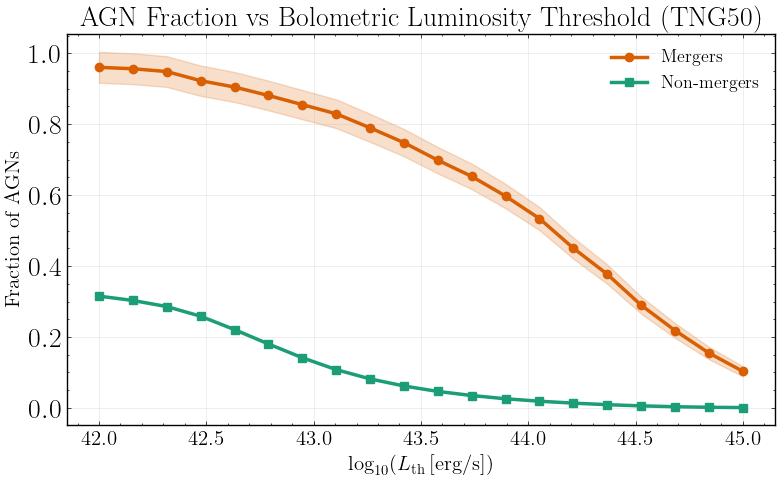

In [46]:
results = calculate_AGN_fractions_vs_threshold(mergers_Lbol, non_mergers_Lbol)

# With q_merger mask
# results = calculate_AGN_fractions_vs_threshold(mergers_Lbol, non_mergers_Lbol, 
#                                                q_merger_mask=q_merger_mask_array)

# Extract results for plotting
Lth_array = results['Lth_array']
fAGN_mergers_array = results['fAGN_mergers']
fAGN_mergers_err = results['fAGN_mergers_err']
fAGN_non_mergers_array = results['fAGN_non_mergers']
fAGN_non_mergers_err = results['fAGN_non_mergers_err']

# Plot
hostplot.set_plot_style(spinewidth=1, linewidth=3, titlesize=20, labelsize=15, 
                        xlabelsize=15, ylabelsize=20, legendsize=15, bold=True)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(np.log10(Lth_array), fAGN_mergers_array, linewidth=2.5, label='Mergers', 
        color='#d95f02', marker='o', markersize=6)
ax.fill_between(np.log10(Lth_array), 
                fAGN_mergers_array - fAGN_mergers_err, 
                fAGN_mergers_array + fAGN_mergers_err, 
                alpha=0.2, color='#d95f02')

ax.plot(np.log10(Lth_array), fAGN_non_mergers_array, linewidth=2.5, label='Non-mergers', 
        color='#1b9e77', marker='s', markersize=6)
ax.fill_between(np.log10(Lth_array), 
                fAGN_non_mergers_array - fAGN_non_mergers_err, 
                fAGN_non_mergers_array + fAGN_non_mergers_err, 
                alpha=0.2, color='#1b9e77')

ax.set_xlabel(r'$\log_{10}(L_{\mathrm{th}} \, [\mathrm{erg/s}])$')
ax.set_ylabel('Fraction of AGNs')
ax.set_title('AGN Fraction vs Bolometric Luminosity Threshold (TNG50)')
ax.legend(loc='upper right', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()

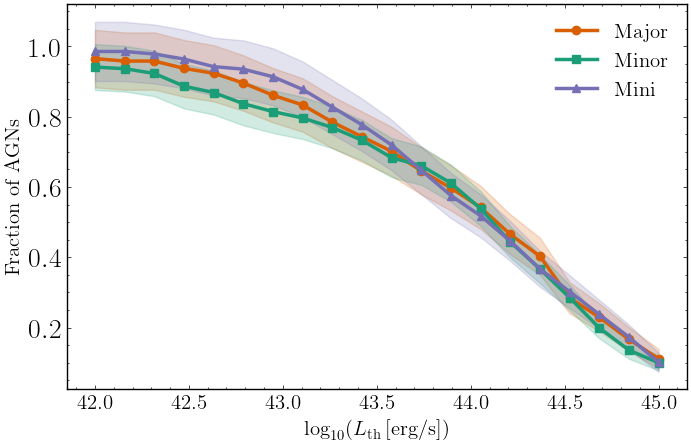

In [53]:
major_merger_mask = TNG_50_pop['merging_population']['q_merger'][:]>0.25
major_merger_results = calculate_AGN_fractions_vs_threshold(mergers_Lbol, non_mergers_Lbol, q_merger_mask=major_merger_mask)
Lth_array = major_merger_results['Lth_array']
fAGN_major_mergers_array = major_merger_results['fAGN_mergers']
fAGN_major_mergers_err = major_merger_results['fAGN_mergers_err']


minor_merger_mask = (TNG_50_pop['merging_population']['q_merger'][:]>0.1) & (TNG_50_pop['merging_population']['q_merger'][:]<=0.25)
minor_merger_results = calculate_AGN_fractions_vs_threshold(mergers_Lbol, non_mergers_Lbol, q_merger_mask=minor_merger_mask)
fAGN_minor_mergers_array = minor_merger_results['fAGN_mergers']
fAGN_minor_mergers_err = minor_merger_results['fAGN_mergers_err']


mini_merger_mask = TNG_50_pop['merging_population']['q_merger'][:]<=0.1
mini_merger_results = calculate_AGN_fractions_vs_threshold(mergers_Lbol, non_mergers_Lbol, q_merger_mask=mini_merger_mask)
fAGN_mini_mergers_array = mini_merger_results['fAGN_mergers']
fAGN_mini_mergers_err = mini_merger_results['fAGN_mergers_err']


# Plot with major and minor mergers
hostplot.set_plot_style(spinewidth=1, linewidth=3, titlesize=20, labelsize=15, 
                        xlabelsize=15, ylabelsize=20, legendsize=15, bold=True)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(np.log10(Lth_array), fAGN_major_mergers_array, linewidth=2.5, label='Major', 
        color='#d95f02', marker='o', markersize=6)
ax.fill_between(np.log10(Lth_array), 
                fAGN_major_mergers_array - fAGN_major_mergers_err, 
                fAGN_major_mergers_array + fAGN_major_mergers_err, 
                alpha=0.2, color='#d95f02')
ax.plot(np.log10(Lth_array), fAGN_minor_mergers_array, linewidth=2.5, label='Minor', 
        color='#1b9e77', marker='s', markersize=6)
ax.fill_between(np.log10(Lth_array), 
                fAGN_minor_mergers_array - fAGN_minor_mergers_err, 
                fAGN_minor_mergers_array + fAGN_minor_mergers_err, 
                alpha=0.2, color='#1b9e77')
ax.plot(np.log10(Lth_array), fAGN_mini_mergers_array, linewidth=2.5, label='Mini', 
        color='#7570b3', marker='^', markersize=6)
ax.fill_between(np.log10(Lth_array), 
                fAGN_mini_mergers_array - fAGN_mini_mergers_err, 
                fAGN_mini_mergers_array + fAGN_mini_mergers_err, 
                alpha=0.2, color='#7570b3')

ax.set_xlabel(r'$\log_{10}(L_{\mathrm{th}} \, [\mathrm{erg/s}])$')
ax.set_ylabel('Fraction of AGNs')
ax.legend(loc='upper right')

In [54]:
def AGN_excess_in_mergers_by_type(sim_objs, sim_name, Lthreshold=43, z_l=0, z_u=4, 
                                   radiative_efficiency=0.2, verbose=True):
    """
    Calculate AGN excess in mergers and break down by merger type (major/minor/mini).
    
    Parameters:
    -----------
    sim_objs : dict
        Dictionary of simulation objects with merger/control populations
    sim_name : str
        Name of simulation to analyze
    Lthreshold : float
        Log10 luminosity threshold (erg/s)
    z_l, z_u : float
        Redshift range
    radiative_efficiency : float
        Radiative efficiency for Lbol calculation
    verbose : bool
        Print results
        
    Returns:
    --------
    tuple of dicts:
        - excess_fractions: {'all': value, 'above_threshold': value}
        - excess_stds: {'all': value, 'above_threshold': value}
        - merger_type_fractions: {'major': {...}, 'minor': {...}, 'mini': {...}}
        - merger_type_stds: {'major': {...}, 'minor': {...}, 'mini': {...}}
    """
    
    Lbol_mergers = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_merging_pop, radiative_efficiency)
    Lbol_control = utils.Lbol_from_BHAR(sim_objs[sim_name].Mdot_control_pop, radiative_efficiency)

    z_mask = (sim_objs[sim_name].z_merging_pop >= z_l) & (sim_objs[sim_name].z_merging_pop < z_u)
    valid_luminosity_mask = (Lbol_mergers > 0) & (Lbol_control > 0) & z_mask
    valid_luminosity_above_threshold_mask = (Lbol_mergers > 10**Lthreshold) & (Lbol_control > 0) & z_mask
    
    Lbol_mergers_filtered = Lbol_mergers[valid_luminosity_mask]
    Lbol_control_filtered = Lbol_control[valid_luminosity_mask]

    MBH_mergers = sim_objs[sim_name].MBH_merging_pop[valid_luminosity_mask]
    MBH_control = sim_objs[sim_name].MBH_control_pop[valid_luminosity_mask]

    if verbose:
        print(f"MBH median (merger/control): {np.median(np.log10(MBH_mergers)):.2f} / {np.median(np.log10(MBH_control)):.2f}")

    # Calculate excess for all valid data
    mergers_higher_Lbol_count = np.sum(Lbol_mergers_filtered > Lbol_control_filtered)
    total_count = len(Lbol_mergers_filtered)
    excess_fraction_all = mergers_higher_Lbol_count / total_count if total_count > 0 else 0
    excess_fraction_all_std = np.sqrt(excess_fraction_all * (1 - excess_fraction_all) / total_count) if total_count > 0 else np.nan

    if verbose:
        print(f"Fraction of mergers with Lbol > control: {excess_fraction_all:.2%} ± {excess_fraction_all_std:.2%} ({mergers_higher_Lbol_count}/{total_count})")

    excess_fractions = {'all': excess_fraction_all}
    excess_stds = {'all': excess_fraction_all_std}
    
    # Initialize merger type dicts
    merger_type_fractions = {'major': {}, 'minor': {}, 'mini': {}}
    merger_type_stds = {'major': {}, 'minor': {}, 'mini': {}}

    if np.sum(valid_luminosity_above_threshold_mask) == 0:
        if verbose:
            print(f"No valid luminosity values above the threshold of 10^{Lthreshold} erg/s for {sim_name} in the redshift range {z_l} to {z_u}.")
        excess_fractions['above_threshold'] = np.nan
        excess_stds['above_threshold'] = np.nan
        for merger_type in ['major', 'minor', 'mini']:
            merger_type_fractions[merger_type] = {'all': np.nan, 'above_threshold': np.nan}
            merger_type_stds[merger_type] = {'all': np.nan, 'above_threshold': np.nan}
        return excess_fractions, excess_stds, merger_type_fractions, merger_type_stds
    
    # Calculate excess above threshold
    Lbol_mergers_above = Lbol_mergers[valid_luminosity_above_threshold_mask]
    Lbol_control_above = Lbol_control[valid_luminosity_above_threshold_mask]
    mergers_higher_Lbol_above_count = np.sum(Lbol_mergers_above > Lbol_control_above)
    total_count_above = len(Lbol_mergers_above)
    excess_fraction_above = mergers_higher_Lbol_above_count / total_count_above if total_count_above > 0 else 0
    excess_fraction_above_std = np.sqrt(excess_fraction_above * (1 - excess_fraction_above) / total_count_above) if total_count_above > 0 else np.nan
    
    if verbose:
        print(f"Fraction of mergers with Lbol > control above 10^{Lthreshold} erg/s: {excess_fraction_above:.2%} ± {excess_fraction_above_std:.2%} ({mergers_higher_Lbol_above_count}/{total_count_above})")
    
    excess_fractions['above_threshold'] = excess_fraction_above
    excess_stds['above_threshold'] = excess_fraction_above_std
    
    # Get merger type masks for all valid mergers
    all_merger_type_masks = {
        'major': sim_objs[sim_name].major_merger_mask[valid_luminosity_mask],
        'minor': sim_objs[sim_name].minor_merger_mask[valid_luminosity_mask],
        'mini': sim_objs[sim_name].mini_merger_mask[valid_luminosity_mask]
    }
    
    # Get merger type masks for above-threshold mergers
    above_merger_type_masks = {
        'major': sim_objs[sim_name].major_merger_mask[valid_luminosity_above_threshold_mask],
        'minor': sim_objs[sim_name].minor_merger_mask[valid_luminosity_above_threshold_mask],
        'mini': sim_objs[sim_name].mini_merger_mask[valid_luminosity_above_threshold_mask]
    }
    
    # Calculate fractions for each merger type
    for merger_type in ['major', 'minor', 'mini']:
        # For all valid mergers
        count_all = np.sum(all_merger_type_masks[merger_type])
        frac_all = count_all / total_count if total_count > 0 else 0
        std_all = np.sqrt(frac_all * (1 - frac_all) / total_count) if total_count > 0 else np.nan
        merger_type_fractions[merger_type]['all'] = frac_all
        merger_type_stds[merger_type]['all'] = std_all
        
        # For above-threshold mergers
        count_above = np.sum(above_merger_type_masks[merger_type])
        frac_above = count_above / total_count_above if total_count_above > 0 else 0
        std_above = np.sqrt(frac_above * (1 - frac_above) / total_count_above) if total_count_above > 0 else np.nan
        merger_type_fractions[merger_type]['above_threshold'] = frac_above
        merger_type_stds[merger_type]['above_threshold'] = std_above
        
        if verbose:
            print(f"  {merger_type} (all): {frac_all:.2%} ± {std_all:.2%}")
            print(f"  {merger_type} (above threshold): {frac_above:.2%} ± {std_above:.2%}")
    
    return excess_fractions, excess_stds, merger_type_fractions, merger_type_stds


# Usage example:
# excess_fractions, excess_stds, merger_type_fractions, merger_type_stds = \
#     AGN_excess_in_mergers_by_type(sim_objs, 'TNG50', Lthreshold=43, z_l=0, z_u=40, verbose=True)